In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history.csv")

print(nav_df.shape)
nav_df.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [4]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [5]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [6]:
results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(fund_returns) > 0:

        var_95 = np.percentile(
            fund_returns,
            5
        )

        cvar_95 = fund_returns[
            fund_returns <= var_95
        ].mean()

        results.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Exported Successfully")

Exported Successfully


In [8]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
top5_funds = (
    nav_df["amfi_code"]
    .value_counts()
    .head(5)
    .index
)

top5_funds

Index([100016, 100025, 100033, 101206, 101207], dtype='int64', name='amfi_code')

In [10]:
rolling_sharpe_df = pd.DataFrame()

for fund in top5_funds:

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    temp["fund"] = str(fund)

    rolling_sharpe_df = pd.concat(
        [rolling_sharpe_df, temp]
    )

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,fund
0,100016,2022-01-03,520.4608,NaN,NaN,100016
1,100016,2022-01-04,515.0971,-0.010306,NaN,100016
2,100016,2022-01-05,521.7239,0.012865,NaN,100016
3,100016,2022-01-06,515.7880,-0.011377,NaN,100016
4,100016,2022-01-07,515.1639,-0.001210,NaN,100016


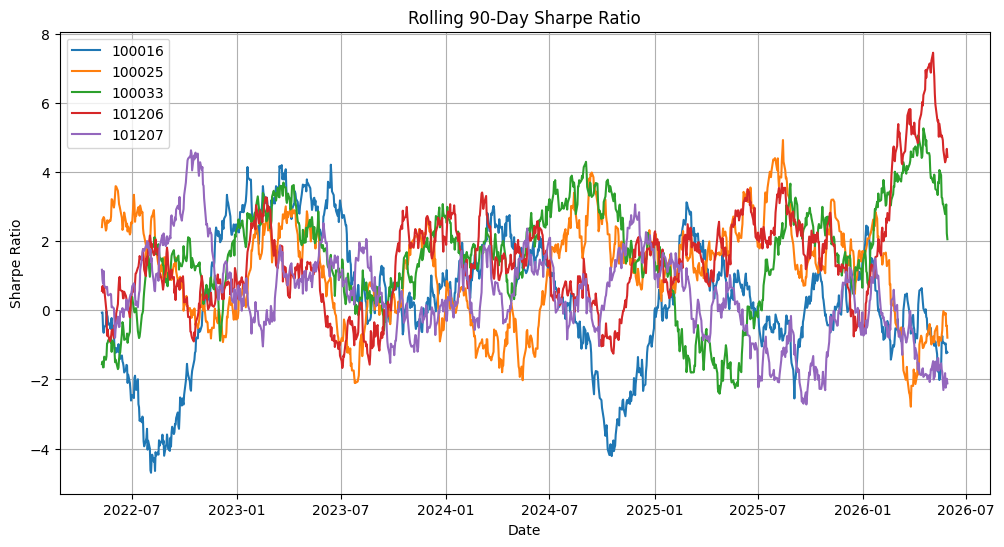

In [11]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
scheme_df = pd.read_csv("../data/processed/07_scheme_performance.csv")

print(
    scheme_df["risk_grade"]
    .value_counts(dropna=False)
)

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(df.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [14]:
txn_df = pd.read_csv("../data/processed/08_investor_transactions.csv")

print(txn_df["transaction_type"].value_counts())

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [15]:
print(txn_df.shape)
txn_df.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [16]:
txn_df = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

txn_df["transaction_date"] = pd.to_datetime(
    txn_df["transaction_date"]
)

txn_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
first_txn = (
    txn_df.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [18]:
txn_df = txn_df.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

txn_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [19]:
sip_df = txn_df[
    txn_df["transaction_type"] == "SIP"
]

avg_sip = (
    sip_df.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.columns = [
    "cohort_year",
    "avg_sip_amount"
]

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [20]:
total_invested = (
    txn_df.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_invested.columns = [
    "cohort_year",
    "total_invested"
]

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [21]:
top_fund = (
    txn_df.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [22]:
sip_txn = txn_df[
    txn_df["transaction_type"] == "SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [23]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [24]:
sip_counts = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

len(eligible_investors)

1362

In [25]:
continuity_df = sip_txn[
    sip_txn["investor_id"]
    .isin(eligible_investors)
]

avg_gap = (
    continuity_df.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

avg_gap.columns = [
    "investor_id",
    "avg_gap_days"
]

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [26]:
avg_gap["status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Active"
)

avg_gap["status"].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [27]:
avg_gap["status"].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [28]:
portfolio_df = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [29]:
portfolio_df[
    ["amfi_code", "sector", "weight_pct"]
].head()

,amfi_code,sector,weight_pct
0,119551,Utilities,13.85
1,119551,Banking,11.19
2,119551,Diversified,9.90
3,119551,Pharma,4.76
4,119551,Paints,10.25


In [30]:
portfolio_df["weight_decimal"] = (
    portfolio_df["weight_pct"] / 100
)

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [31]:
hhi_df = (
    portfolio_df.groupby("amfi_code")
    .apply(
        lambda x: (
            x["weight_decimal"] ** 2
        ).sum()
    )
    .reset_index(name="HHI")
)

hhi_df.head()

C:\Users\91630\AppData\Local\Temp\ipykernel_11300\4042238742.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [32]:
import pandas as pd

df = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(df["risk_grade"].value_counts())

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [33]:
print(var_cvar_df.shape)

(40, 3)
